### Lennard-Jones Potential
$$ U = 4\epsilon\left[ \left( \dfrac{\sigma}{r} \right)^{12} - \left( \dfrac{\sigma}{r} \right)^6 \right] $$
and
$$ |\vec{F}| = 4\epsilon\left[ \dfrac{12}{r}\left( \dfrac{\sigma}{r} \right)^{12} - \dfrac{6}{r}\left( \dfrac{\sigma}{r} \right)^6 \right] $$

In [169]:
import numpy as np
import numpy.random as r
import matplotlib.pyplot as plt

In [170]:
# some parameters
N_particles = 50              # number of particles
m = 1.0                       # mass
ep = 1.0                      # epsilon (in LJ potential)
sigma = 1.0                   # sigma (in LJ potential)

In [171]:
# function to return KE,PE,TE and Force
def compute(pos,momenta):
    U = 0.0
    F_arr = np.zeros_like(pos)
    # we shall be following the ordering i<j
    for i in range(N_particles):
        for j in range(i+1,N_particles):
            # rel. postion vector
            r_ij = pos[i]-pos[j]
            r = np.linalg.norm(r_ij)
            r_ij_hat = r_ij/r                   # unit vect in direction of force

            # computing potential energy and force
            U += 4*ep*((sigma/r)**12 - (sigma/r)**6)
            F = 4*ep*(12*(sigma/r)**12/r - 6*(sigma/r)**6/r)*r_ij_hat
            F_arr[i] += F
            F_arr[j] -= F
    K = np.sum(0.5*momenta**2/m)
    return K,U,U+K, F_arr

In [172]:
# initializing positions and momenta
r.seed(10)
pos_ini = r.random((N_particles,2)) * 100
momenta_ini = r.random((N_particles,2))

# removing center of mass momenta
# this is done to ensure that the pseudo-box remains still
momenta_ini -= np.mean(momenta_ini,axis = 0)

### Symplectic Scheme Used

$$ q_{n+1/2} = q_n + \dfrac{h}{2}T_p(p_n) $$
$$ p_{n+1} = p_n - hU_q(q_{n+1/2}) $$
$$ q_{n+1} = q_{n+1/2} + \dfrac{h}{2}T_p(p_{n+1}) $$

In [177]:
# writing the solver part
t0,tf,h = 0.0,10.0,0.001
N = int((tf-t0)/h)+1

pos_arr = np.zeros((N,N_particles,2),float)
momenta_arr = np.zeros((N,N_particles,2),float)
pos_arr[0] = pos_ini
momenta_arr[0] = momenta_ini

KE_arr = np.zeros((N,),float)
PE_arr = np.zeros((N,),float)
TE_arr = np.zeros((N,),float)
F_arr = np.zeros((N,N_particles,2),float)

KE_arr[0],PE_arr[0],TE_arr[0],F_arr[0] = compute(pos_ini,momenta_ini)


for i in range(N-1):    
    # second order symplectic method
    pos_half = pos_arr[i] + 0.5*h*momenta_arr[i]/m
    _,_,_,F_half = compute(pos_half,momenta_ini)             # note that any momenta will work for this line
    momenta_arr[i+1] = momenta_arr[i] + h*F_half
    pos_arr[i+1] = pos_half + 0.5*h*momenta_arr[i+1]/m

    KE_arr[i+1],PE_arr[i+1],TE_arr[i+1],F_arr[i+1] = compute(pos_arr[i+1],momenta_arr[i+1])

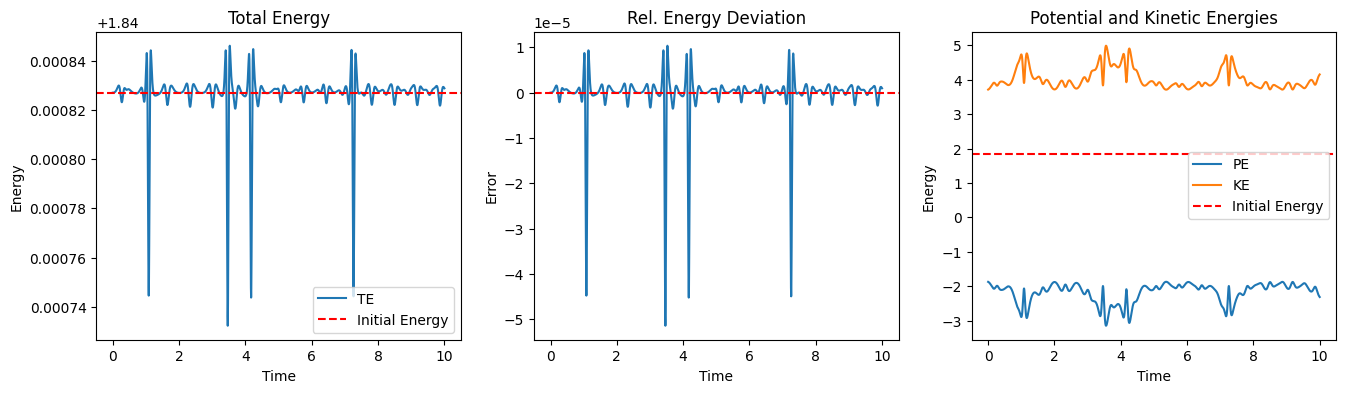

In [181]:
# checking the energy of the system
t_arr = np.linspace(t0,tf,N)
plt.figure(figsize = (16,4))
plt.subplot(1,3,1)
plt.plot(t_arr,TE_arr,label = 'TE')
plt.title("Total Energy")
plt.xlabel('Time')
plt.ylabel('Energy')
plt.axhline(TE_arr[0],ls = '--',c = 'red',label = 'Initial Energy')
plt.legend()
plt.subplot(1,3,2)
plt.plot(t_arr,(TE_arr-TE_arr[0])/TE_arr[0])
plt.title("Rel. Energy Deviation")
plt.xlabel('Time')
plt.ylabel('Error')
plt.axhline(0,ls = '--',c = 'red')
plt.subplot(1,3,3)
plt.plot(t_arr,PE_arr,label = 'PE')
plt.plot(t_arr,KE_arr,label = 'KE')
plt.title("Potential and Kinetic Energies")
plt.xlabel('Time')
plt.ylabel('Energy')
plt.axhline(TE_arr[0],ls = '--',c = 'red',label = 'Initial Energy')
plt.legend()
plt.show()

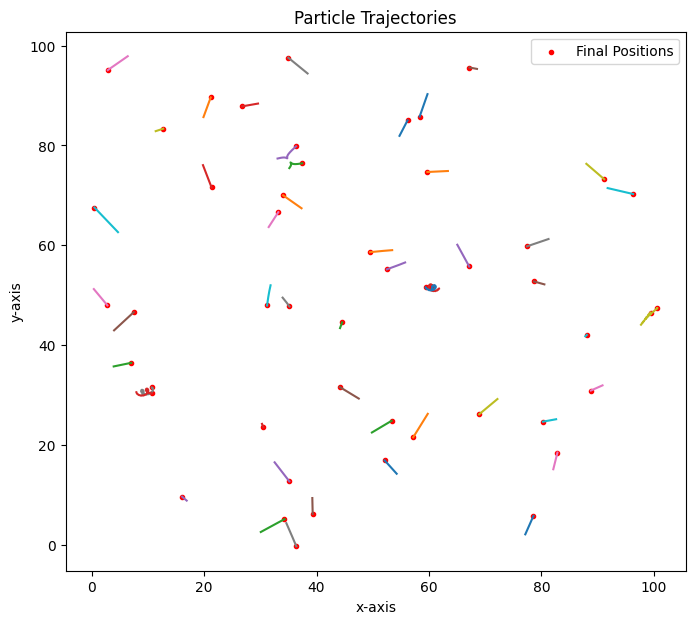

In [179]:
N_show = 50                     # <= N_particles
plt.figure(figsize = (8,7))
plt.scatter(pos_arr[-1,:N_show,0],pos_arr[-1,:N_show,1],label = 'Final Positions',marker = '.',c='r')
for i in range(N_show):
    plt.plot(
        pos_arr[:,i,0],
        pos_arr[:,i,1]
    )
plt.title("Particle Trajectories")
plt.xlabel('x-axis')
plt.ylabel('y-axis')
plt.legend()
plt.show()